In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import lu_factor, lu_solve
import sympy as sp

In [17]:
#parameters

nu_inf = 1.5e-6      # Kinematic viscosity (m^2/s)
u_inf = 30           # Freestream velocity (m/s)
L = 1                # Characteristic length (m)
delta = 0.005        # Initial boundary layer thickness (m)

Ny = 150  #y partitions
y_max = 10*delta
s = 10    #Grid stretching factor

# Estimate initial x0 assuming standard laminar growth: delta approx 5.0 * sqrt(nu*x / u_inf)
x0 = (delta/5.0)**2*(u_inf/nu_inf) 
X_total = 40*L     # independent var length
dx = 0.01            # Marching step size in x
Nx = int(X_total/dx) # x partitions

# Uniform computational grid (eta)
eta = np.linspace(0, 1, Ny)
d_eta = eta[1] - eta[0]

# Physical stretched grid (y)
y = y_max * (np.sinh(s * eta) / np.sinh(s))

# proposed stretching grid derivatives
deta_dy = np.sinh(s) / (s * y_max * np.cosh(s * eta))
d2eta_dy2 = -(np.sinh(s)**2 * np.sinh(s * eta)) / (s * y_max**2 * np.cosh(s * eta)**3)

N_int = Ny - 2

In [18]:
# central diff for eta
D1 = np.zeros((Ny, Ny))
D2 = np.zeros((Ny, Ny))

for i in range(1, Ny - 1):
    if i == 1 or i == Ny - 2:
        # 2nd order cd, for boundary-adjacent points
        D1[i, i-1] = -1/(2*d_eta)
        D1[i, i+1] = 1/(2*d_eta)
        
        D2[i, i-1] = 1/d_eta**2
        D2[i, i] = -2/d_eta**2
        D2[i, i+1] = 1/d_eta**2
    else:
        # 4th order cd, for interior points
        D1[i, i-2] = 1/(12*d_eta)
        D1[i, i-1] = -8/(12*d_eta)
        D1[i, i+1] = 8/(12*d_eta)
        D1[i, i+2] = -1/(12*d_eta)
        
        D2[i, i-2] = -1/(12*d_eta**2)
        D2[i, i-1] = 16/(12*d_eta**2)
        D2[i, i] = -30/(12*d_eta**2)
        D2[i, i+1] = 16/(12*d_eta**2)
        D2[i, i+2] = -1/(12*d_eta**2)

In [19]:
u = np.zeros(Ny)  #init u
v = np.zeros(Ny)  #init v

#piecewise IC for u
for i in range(Ny):
    if y[i]/delta <= 1:
        u[i] = u_inf*(y[i]/delta*(3/2-1/2*((y[i]/delta)**2)))
    else:
        u[i] = u_inf

x_vals = [1000, 2000, 3000, 4000] # x-steps to store numerical sols
u_store_numer = {0: u.copy()}
v_store_numer = {0: v.copy()}

for n in range(1, Nx + 1):
    
    # 1. Calculate spatial differential operator matrix L_matrix
    L_matrix = np.zeros((Ny, Ny))
    for i in range(1, Ny - 1):
        alpha = nu_inf * deta_dy[i]**2
        beta = nu_inf * d2eta_dy2[i] - v[i] * deta_dy[i]

        L_matrix[i, :] = (alpha * D2[i, :] + beta * D1[i, :])
        
    #Au=b
    U_diag = np.diag(u) 
    
    A = U_diag - 0.5*dx*L_matrix
    b_mat = U_diag + 0.5*dx*L_matrix

    #top boundary 
    A[-1, :] = 0; 
    A[-1, -1] = 1; 
    b_mat[-1, :] = 0; 
    b_mat[-1, -1] = 1 
    
    #bottom boundary
    A[0, :] = 0; 
    A[0, 0] = 1; 
    b_mat[0, :] = 0; 
    b_mat[0, 0] = 1        
    
    lu, piv = lu_factor(A) 
    
    #solving b
    b = b_mat@u
    b[0] = 0 
    b[-1] = u_inf 
    
    u_new = lu_solve((lu, piv), b)
    u_new[0] = 0
    u_new[-1] = u_inf
    
    # Update v
    du_dx = (u_new - u) / dx
    v_new = np.zeros(Ny)
    for i in range(1, Ny):
        # trapezoidal integration for continuity equation
        v_new[i] = v_new[i-1] - 0.5*(y[i] - y[i-1]) * (du_dx[i] + du_dx[i-1])
        
    u = u_new.copy()
    v = v_new.copy()

    if n in x_vals:
        u_store_numer[n] = u.copy() 
        v_store_numer[n] = v.copy()

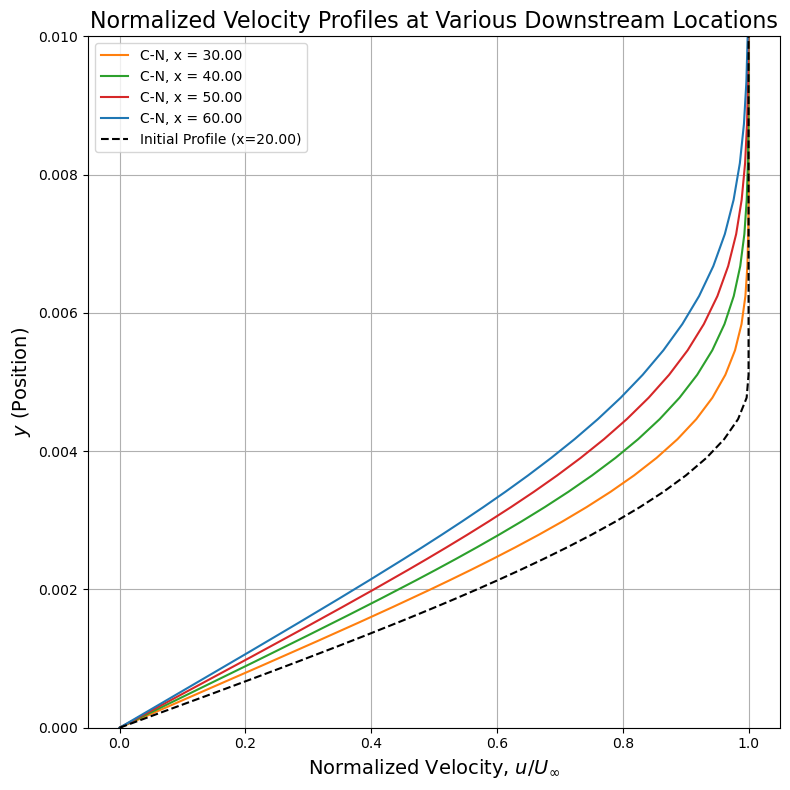

In [20]:
plt.figure(figsize=(8, 8))
colors = [ 'tab:orange', 'tab:green', 'tab:red','tab:blue']
markevery = 2

for idx, n in enumerate(x_vals):
    x_now = x0 + n * dx
    label_text = f'x = {x_now:.2f}'
    
    # numerical
    plt.plot(u_store_numer[n] / u_inf, y, '-', color=colors[idx], markersize=4, label=f'C-N, {label_text}')

plt.plot(u_store_numer[0] / u_inf, y, '--', color='k', label=f'Initial Profile (x={x0:.2f})')

plt.title('Normalized Velocity Profiles at Various Downstream Locations', fontsize=16)
plt.xlabel(r'Normalized Velocity, $u / U_{\infty}$', fontsize=14)
plt.ylabel(r'$y$ (Position)', fontsize=14)
plt.ylim(0, 0.01) 
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Verify $\eta$ derivatives with symbolic solver:

In [ ]:
eta, s, y_max = sp.symbols('eta s y_max')

y = y_max * sp.sinh(s*eta) / sp.sinh(s)
dy_deta = sp.diff(y, eta)
d_eta=sp.simplify(dy_deta)
deta_dy = sp.simplify(1 / dy_deta)
d2_eta = sp.simplify(deta_dy * sp.diff(deta_dy, eta))
print(f"{sp.latex(d_eta)}\n")
print(f"{sp.latex(d2_eta)}")

\frac{s y_{max} \cosh{\left(\eta s \right)}}{\sinh{\left(s \right)}}

- \frac{\sinh^{2}{\left(s \right)} \sinh{\left(\eta s \right)}}{s y_{max}^{2} \cosh^{3}{\left(\eta s \right)}}


$$
\frac{\partial\eta}{\partial y} = \frac{s y_{max} \cosh{\left(\eta s \right)}}{\sinh{\left(s \right)}}
$$

$$
\frac{\partial^2\eta}{\partial y^2}=- \frac{\sinh^{2}{\left(s \right)} \sinh{\left(\eta s \right)}}{s y_{max}^{2} \cosh^{3}{\left(\eta s \right)}}
$$